<a href="https://colab.research.google.com/github/Teolinlesp/desafio3PythonTelecom-X-Parte2/blob/main/DesafioTelecomParte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ Preparación de los Datos

## Extracción del Archivo Tratado Parte 1

In [60]:
import pandas as pd
datosTelecom2 = pd.read_csv("datos_tratados.csv")
datosTelecom2.head()

,ID_Cliente,Abandono,Género,Adulto_Mayor,Pareja,Dependientes,Antigüedad_Meses,Teléfono_Servicio,Teléfono_Múltiples_Líneas,Internet_Tipo_Servicio,...,Internet_Protección_Dispositivo,Internet_Soporte_Técnico,Internet_TV_Streaming,Internet_Películas_Streaming,Cuenta_Tipo_Contrato,Cuenta_Facturación_Sin_Papel,Cuenta_Método_Pago,Cuenta_Cargo_Mensual,Cuenta_Cargo_Total,Cuentas_Diarias
0,0002-orfbo,0.0,female,0,1,1,9,1,0.0,dsl,...,0.0,1.0,1.0,0.0,one year,1,mailed check,65.6,593.30,2.186667
1,0003-mknfe,0.0,male,0,0,0,9,1,1.0,dsl,...,0.0,0.0,0.0,1.0,month-to-month,0,mailed check,59.9,542.40,1.996667
2,0004-tlhlj,1.0,male,0,0,0,4,1,0.0,fiber optic,...,1.0,0.0,0.0,0.0,month-to-month,1,electronic check,73.9,280.85,2.463333
3,0011-igkff,1.0,male,1,1,0,13,1,0.0,fiber optic,...,1.0,0.0,1.0,1.0,month-to-month,1,electronic check,98.0,1237.85,3.266667
4,0013-exchz,1.0,female,1,1,0,3,1,0.0,fiber optic,...,0.0,1.0,1.0,0.0,month-to-month,1,mailed check,83.9,267.40,2.796667


In [61]:
columnas_binarias = [
    'Abandono',
    'Teléfono_Múltiples_Líneas',
    'Internet_Protección_Dispositivo',
    'Internet_Soporte_Técnico',
    'Internet_Películas_Streaming'
]

for col in columnas_binarias:
    datosTelecom2[col] = datosTelecom2[col].astype('Int64')
datosTelecom2.head()

,ID_Cliente,Abandono,Género,Adulto_Mayor,Pareja,Dependientes,Antigüedad_Meses,Teléfono_Servicio,Teléfono_Múltiples_Líneas,Internet_Tipo_Servicio,...,Internet_Protección_Dispositivo,Internet_Soporte_Técnico,Internet_TV_Streaming,Internet_Películas_Streaming,Cuenta_Tipo_Contrato,Cuenta_Facturación_Sin_Papel,Cuenta_Método_Pago,Cuenta_Cargo_Mensual,Cuenta_Cargo_Total,Cuentas_Diarias
0,0002-orfbo,0,female,0,1,1,9,1,0,dsl,...,0,1,1.0,0,one year,1,mailed check,65.6,593.30,2.186667
1,0003-mknfe,0,male,0,0,0,9,1,1,dsl,...,0,0,0.0,1,month-to-month,0,mailed check,59.9,542.40,1.996667
2,0004-tlhlj,1,male,0,0,0,4,1,0,fiber optic,...,1,0,0.0,0,month-to-month,1,electronic check,73.9,280.85,2.463333
3,0011-igkff,1,male,1,1,0,13,1,0,fiber optic,...,1,0,1.0,1,month-to-month,1,electronic check,98.0,1237.85,3.266667
4,0013-exchz,1,female,1,1,0,3,1,0,fiber optic,...,0,1,1.0,0,month-to-month,1,mailed check,83.9,267.40,2.796667


### Eliminar Columnas no relevantes

In [62]:
datosTelecom2 = datosTelecom2.drop(columns=["ID_Cliente", "Cuentas_Diarias"], errors="ignore")
datosTelecom2.head()

,Abandono,Género,Adulto_Mayor,Pareja,Dependientes,Antigüedad_Meses,Teléfono_Servicio,Teléfono_Múltiples_Líneas,Internet_Tipo_Servicio,Internet_Seguridad_En_Línea,Internet_Respaldo_En_Línea,Internet_Protección_Dispositivo,Internet_Soporte_Técnico,Internet_TV_Streaming,Internet_Películas_Streaming,Cuenta_Tipo_Contrato,Cuenta_Facturación_Sin_Papel,Cuenta_Método_Pago,Cuenta_Cargo_Mensual,Cuenta_Cargo_Total
0,0,female,0,1,1,9,1,0,dsl,no,yes,0,1,1.0,0,one year,1,mailed check,65.6,593.30
1,0,male,0,0,0,9,1,1,dsl,no,no,0,0,0.0,1,month-to-month,0,mailed check,59.9,542.40
2,1,male,0,0,0,4,1,0,fiber optic,no,no,1,0,0.0,0,month-to-month,1,electronic check,73.9,280.85
3,1,male,1,1,0,13,1,0,fiber optic,no,yes,1,0,1.0,1,month-to-month,1,electronic check,98.0,1237.85
4,1,female,1,1,0,3,1,0,fiber optic,no,no,0,1,1.0,0,month-to-month,1,mailed check,83.9,267.40


### Separar variable objetivo (Churn)

In [63]:
datosTelecom2["Abandono"].value_counts()

,count
Abandono,
0,5174
1,1869


In [64]:
datosTelecom2 = datosTelecom2.dropna()
X = datosTelecom2.drop("Abandono", axis=1)
y = datosTelecom2["Abandono"]

In [65]:
y.isnull().sum()

np.int64(0)

## Encoding
Convertimos variables categóricas en numéricas.

In [66]:
X = pd.get_dummies(X, drop_first=True)

### Verificación de la Proporción de Cancelación (Churn)

In [67]:
proporcion = y.value_counts(normalize=True)
print(proporcion)

Abandono
0    0.671772
1    0.328228
Name: proportion, dtype: Float64


In [68]:
# En porcentaje para ver desvalance
print(y.value_counts(normalize=True) * 100)

Abandono
0    67.177152
1    32.822848
Name: proportion, dtype: Float64


## Balanceo de Clases

La variable objetivo presenta un desbalance moderado (73.46% clientes activos y 26.53% clientes que abandonaron).

Dado que el desbalance no es extremo, se decidió inicialmente no aplicar técnicas de balanceo y evaluar el desempeño de los modelos utilizando métricas adecuadas como Recall y F1-score.

## División de Datos (Train/Test)

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Normalización o Estandarización (si es necesario)
Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 🔎 Correlación y Selección de Variables

### Análisis de Correlación

In [71]:
df_modelo = X.copy()
df_modelo["Abandono"] = y

### Matriz de correlación

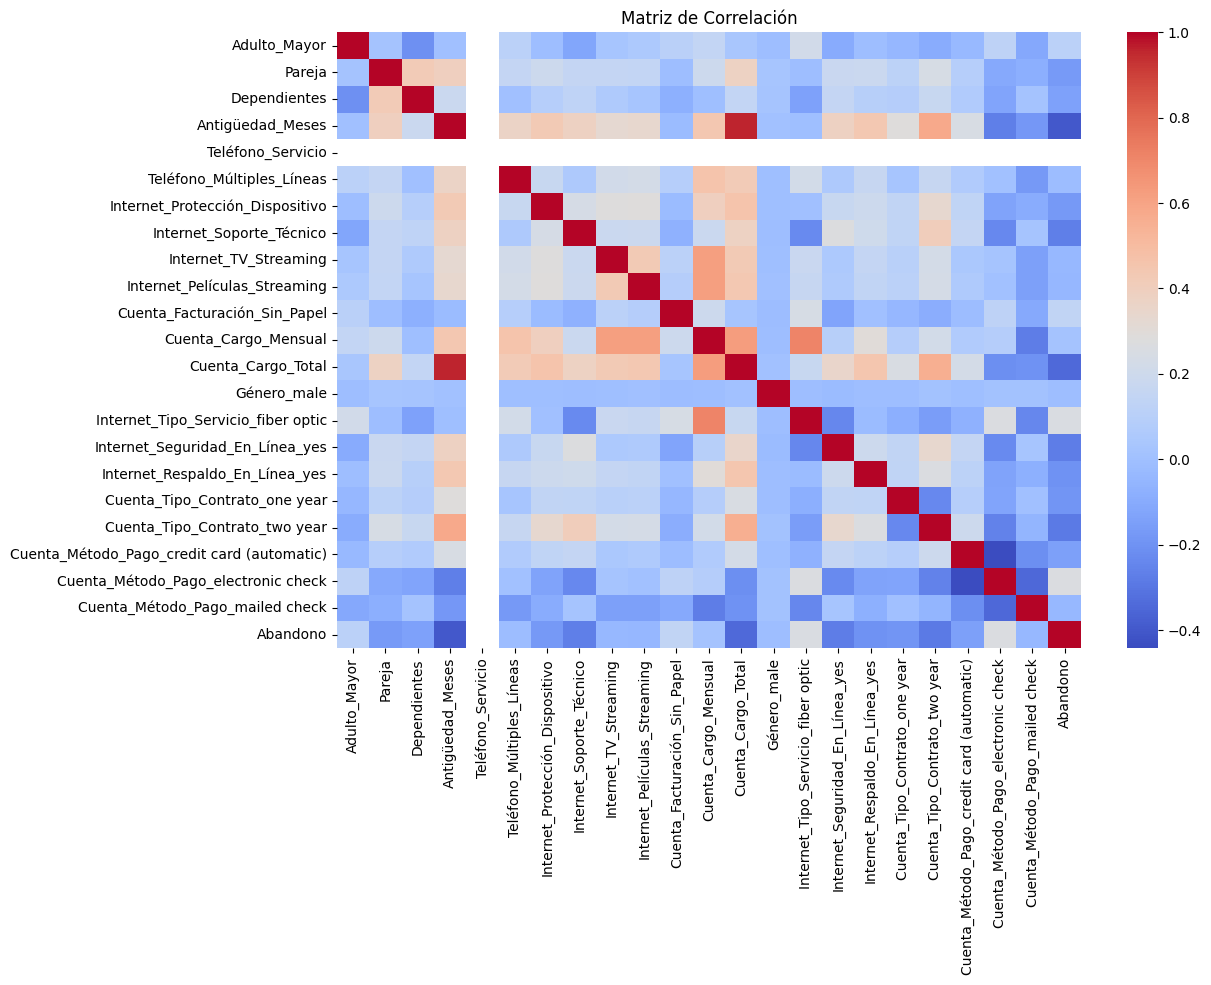

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df_modelo.corr(), cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

### Análisis Dirigido

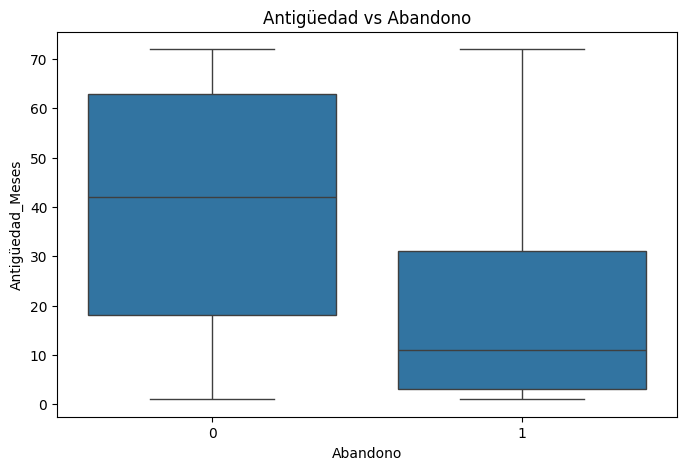

In [73]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Abandono", y="Antigüedad_Meses", data=datosTelecom2)
plt.title("Antigüedad vs Abandono")
plt.show()

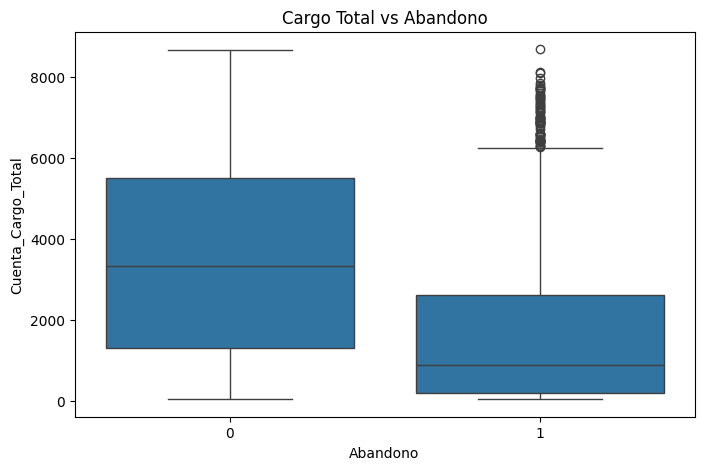

In [74]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Abandono", y="Cuenta_Cargo_Total", data=datosTelecom2)
plt.title("Cargo Total vs Abandono")
plt.show()

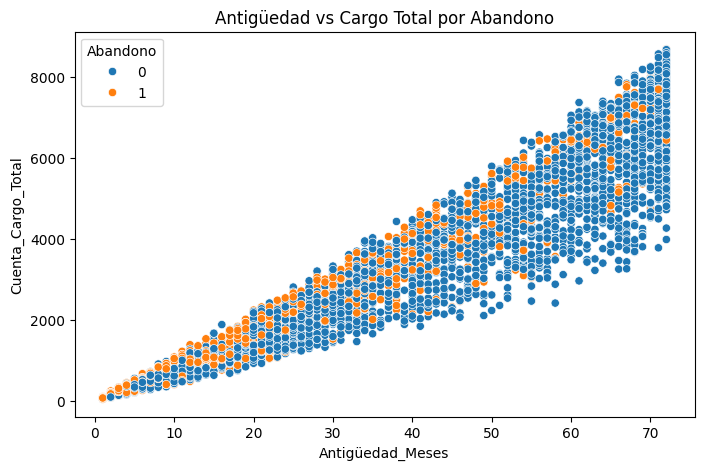

In [75]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Antigüedad_Meses",
                y="Cuenta_Cargo_Total",
                hue="Abandono",
                data=datosTelecom2)
plt.title("Antigüedad vs Cargo Total por Abandono")
plt.show()

## 🤖 Modelado Predictivo

### Separación de Datos

### Creación de Modelos

### Modelo 1 Regresión Logística

In [78]:
from sklearn.linear_model import LogisticRegression

modelo_log = LogisticRegression(max_iter=1000, random_state=42)

modelo_log.fit(X_train_scaled, y_train)

y_pred_log = modelo_log.predict(X_test_scaled)

### Modelo 2 Random Forest

In [79]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

## Evaluación de los Modelos

In [80]:
# Importando métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

### Evaluación Regresión Logística

In [81]:
print("Regresión Logística")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

Regresión Logística
Accuracy: 0.7569803516028956
Precision: 0.6413793103448275
Recall: 0.5867507886435331
F1-score: 0.6128500823723229


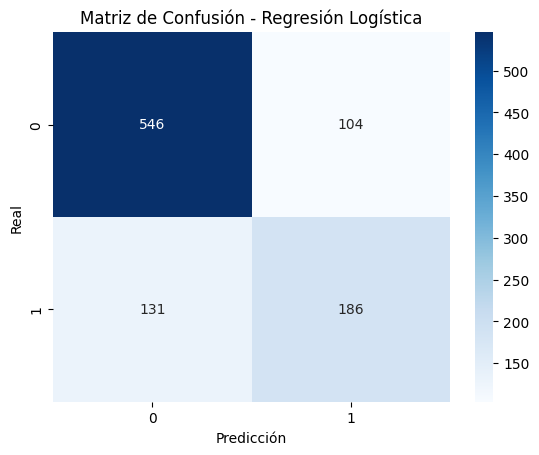

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

### Evaluación Random Forest

In [83]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

Random Forest
Accuracy: 0.7414684591520165
Precision: 0.6283524904214559
Recall: 0.5173501577287066
F1-score: 0.5674740484429066


In [ ]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

## Evaluación de overfitting

In [84]:
print("Accuracy entrenamiento - Logística:", modelo_log.score(X_train_scaled, y_train))
print("Accuracy prueba - Logística:", modelo_log.score(X_test_scaled, y_test))

print("Accuracy entrenamiento - RF:", modelo_rf.score(X_train, y_train))
print("Accuracy prueba - RF:", modelo_rf.score(X_test, y_test))

Accuracy entrenamiento - Logística: 0.7671410090556274
Accuracy prueba - Logística: 0.7569803516028956
Accuracy entrenamiento - RF: 0.9989650711513584
Accuracy prueba - RF: 0.7414684591520165


In [87]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
}).sort_values(by="Importancia", ascending=False)

importancias.head(10)

,Variable,Importancia
12,Cuenta_Cargo_Total,0.207869
11,Cuenta_Cargo_Mensual,0.172744
3,Antigüedad_Meses,0.170979
14,Internet_Tipo_Servicio_fiber optic,0.040543
15,Internet_Seguridad_En_Línea_yes,0.034948
7,Internet_Soporte_Técnico,0.034009
13,Género_male,0.029603
20,Cuenta_Método_Pago_electronic check,0.029480
10,Cuenta_Facturación_Sin_Papel,0.027296
16,Internet_Respaldo_En_Línea_yes,0.025793


In [88]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
}).sort_values(by="Importancia", ascending=False)

importancias.head(10)

,Variable,Importancia
12,Cuenta_Cargo_Total,0.207869
11,Cuenta_Cargo_Mensual,0.172744
3,Antigüedad_Meses,0.170979
14,Internet_Tipo_Servicio_fiber optic,0.040543
15,Internet_Seguridad_En_Línea_yes,0.034948
7,Internet_Soporte_Técnico,0.034009
13,Género_male,0.029603
20,Cuenta_Método_Pago_electronic check,0.029480
10,Cuenta_Facturación_Sin_Papel,0.027296
16,Internet_Respaldo_En_Línea_yes,0.025793


## 📋 Interpretación y Conclusiones

###🔎 Análisis de la Importancia de las Variables

Después de entrenar y evaluar los modelos predictivos para la cancelación de clientes, se realizó un análisis de las variables más relevantes en cada modelo.

El modelo Random Forest identificó como variables más relevantes para la cancelación:

Cuenta_Cargo_Total (20.7%)

Cuenta_Cargo_Mensual (17.2%)

Antigüedad_Meses (17.0%)

Estas tres variables concentran más del 55% de la importancia total del modelo, lo que indica que los factores económicos y el tiempo de permanencia son determinantes en la cancelación.

También influyen:

Internet_Tipo_Servicio_fiber optic

Internet_Soporte_Técnico

Internet_Seguridad_En_Línea_yes

Cuenta_Método_Pago_electronic check

### 📌 Interpretación

Los clientes con mayores cargos presentan mayor riesgo de cancelación.

Los clientes con menor antigüedad tienden a abandonar más el servicio.

Los servicios adicionales (seguridad, soporte, respaldo) favorecen la permanencia.

El método de pago electronic check aparece asociado a mayor riesgo.

### 🎯 Principales Factores de Cancelación

Nivel de gasto mensual.

Total acumulado pagado.

Tiempo como cliente.

Tipo de servicio contratado.

Método de pago.

### 💡 Estrategias de Retención

Ofrecer planes personalizados o descuentos a clientes con cargos elevados.

Implementar beneficios por antigüedad.

Promover paquetes con servicios adicionales.

Incentivar métodos de pago automáticos.

### 🏁 Conclusión

El modelo Random Forest permitió identificar que la cancelación está principalmente influenciada por factores económicos y de permanencia.

La aplicación de estrategias enfocadas en precio, fidelización y servicios complementarios puede reducir significativamente el abandono y mejorar la retención de clientes.